<a href="https://colab.research.google.com/github/DaniloDuque/neural-network/blob/main/src/tp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 — Redes Neuronales

Este notebook está organizado en tres secciones principales:

1. **Two Moons** — clasificación binaria no lineal para verificar la capacidad del MLP.
2. **Clasificador en R²** — 4 configuraciones de MLP (M=20/2, con/sin momentum) sobre datos separables y no separables.
3. **ACRIMA** — clasificación de imágenes de fondo de ojo (glaucoma vs. no glaucoma).

**Modelo:** Perceptrón Multicapa con descenso de gradiente con momentum (Bishop, 2006).  
**Configuraciones evaluadas:** M ∈ {2, 20}, γ ∈ {0.0, 0.9}, α = 0.01.

## Configuración del entorno

Se clona el repositorio si se ejecuta en Google Colab, se agrega `src/` al path de Python y se configuran las credenciales de Kaggle necesarias para la Sección 3.

In [1]:
## @brief Configura el entorno de ejecución (Colab o local).
#  Clona el repositorio si se ejecuta en Google Colab y ajusta el directorio de trabajo.
import os, sys
from dotenv import load_dotenv

if 'google.colab' in sys.modules:
    if not os.path.exists('neural-network'):
        os.system('git clone https://github.com/DaniloDuque/neural-network.git')
    if os.path.basename(os.getcwd()) != 'neural-network':
        os.chdir('neural-network')
    os.system('git pull')

sys.path.insert(0, os.path.abspath('src'))

In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
        print('Credenciales cargadas desde Colab Secrets.')
    except Exception:
        # Corriendo desde VS Code con extensión Colab — usar .env
        load_dotenv()
        print('Credenciales cargadas desde .env (extensión VS Code).')
else:
    kaggle_cfg = os.path.expanduser('~/.config/kaggle/kaggle.json')
    kagglehub_cache = os.path.expanduser('~/.cache/kagglehub/datasets/toaharahmanratul/acrima-dataset')
    if os.path.exists(kaggle_cfg):
        print(f'Credenciales encontradas en {kaggle_cfg}')
    elif os.path.exists(kagglehub_cache):
        print('Dataset ACRIMA ya en caché local — no se requieren credenciales.')
    else:
        print('ADVERTENCIA: no se encontró kaggle.json')

Credenciales cargadas desde .env (extensión VS Code).


## Dependencias

Se instalan las dependencias necesarias para ejecutar el notebook.

In [3]:
## @brief Instala dependencias adicionales no incluidas en Colab.
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'kagglehub==0.3.13', 'Pillow', '-q'],
               check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'kagglehub==0.3.13', 'Pillow', '-q'], returncode=0)

## Dependencias e importaciones

Se importan todos los módulos del proyecto y se detecta el dispositivo de cómputo.

In [4]:
## @brief Importa todos los módulos del proyecto y configura el entorno.
#  Detecta el dispositivo disponible (CUDA o CPU) para pasarlo a las funciones de biblioteca.
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
from PIL import Image
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import kagglehub

from multilayer_perceptron import MultilayerPerceptron
from data_generator        import generate_data
from data_classifier       import train_all_configs
from visualization         import (plot_datasets, plot_error_matrix,
                                   print_convergence_table, convergence_dataframe)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RANDOM_SEED=42

Dispositivo: cpu


---
# Sección 1 — Two Moons: Clasificación Binaria No Lineal

Demostración del MLP sobre el dataset Two Moons para verificar que la red aprende fronteras de decisión no lineales.

In [5]:
## @brief Entrena MLP sobre Two Moons y visualiza la superficie de decisión.
torch.manual_seed(RANDOM_SEED)

X_np, y_np = make_moons(n_samples=400, noise=0.15, random_state=RANDOM_SEED)
X_np = (X_np - X_np.min(0)) / (X_np.max(0) - X_np.min(0))
X_moons = torch.FloatTensor(X_np).to(device)
T_moons = torch.FloatTensor(y_np).unsqueeze(1).to(device)

mlp_moons = MultilayerPerceptron([2, 128, 1], alpha=1.5, gamma=0.95, max_weights=0.01, device=device)

errors, _ = mlp_moons.train_mlp(50000, X_moons, T_moons)

acc = (mlp_moons.predict(X_moons).squeeze().cpu() == torch.tensor(y_np)).float().mean().item()
print(f'Error final: {errors[-1]:.4f}  |  Accuracy: {acc*100:.1f}%')

Error final: 0.0054  |  Accuracy: 99.3%


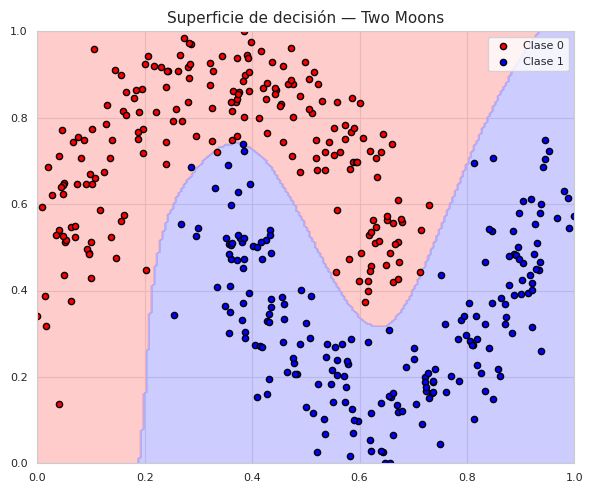

In [6]:
## @brief Visualiza la superficie de decisión del MLP sobre Two Moons.
h = 0.005
xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
Z = mlp_moons.predict(grid).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.6)
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='red',  label='Clase 0', edgecolors='k', s=20)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='blue', label='Clase 1', edgecolors='k', s=20)
plt.title('Superficie de decisión — Two Moons')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'two_moons.pdf', bbox_inches='tight')
plt.show()

---
# Sección 3 — Clasificador de datos en R²

Se generan dos datasets (separable / no-separable) y se entrenan 4 configuraciones de MLP:

| Config | M  | γ   | Descripción               |
|--------|----|-----|---------------------------|
| A      | 20 | 0.9 | 20 neuronas, con momentum |
| B      | 20 | 0.0 | 20 neuronas, sin momentum |
| C      | 2  | 0.9 | 2 neuronas, con momentum  |
| D      | 2  | 0.0 | 2 neuronas, sin momentum  |

Partición 80% entrenamiento / 20% validación. α = 0.01 fijo para todas las configuraciones.

In [7]:
## @brief Define hiperparámetros globales para la sección 2.
NUM_EPOCHS = 50

## 3.1 — Generación de datos

In [8]:
## @brief Genera los datasets separable y no-separable con split 80/20.
X_train_s, X_val_s, T_train_s, T_val_s = generate_data(
    separable=True,  n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)
X_train_ns, X_val_ns, T_train_ns, T_val_ns = generate_data(
    separable=False, n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)

print(f'Separable    — train: {X_train_s.shape},  val: {X_val_s.shape}')
print(f'No-separable — train: {X_train_ns.shape}, val: {X_val_ns.shape}')

Separable    — train: torch.Size([400, 2]),  val: torch.Size([100, 2])
No-separable — train: torch.Size([400, 2]), val: torch.Size([100, 2])


## 3.2 — Visualización de los datos

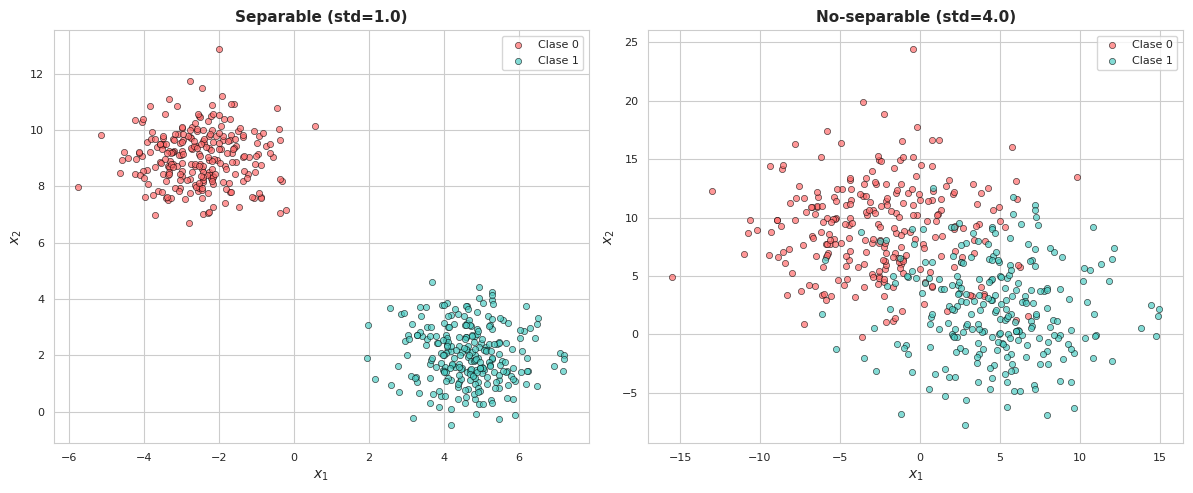

In [9]:
## @brief Muestra scatter de ambos datasets (train + val combinados).
X_sep_full   = torch.cat([X_train_s,  X_val_s],  dim=0).cpu()
T_sep_full   = torch.cat([T_train_s,  T_val_s],  dim=0).cpu()
X_nosep_full = torch.cat([X_train_ns, X_val_ns], dim=0).cpu()
T_nosep_full = torch.cat([T_train_ns, T_val_ns], dim=0).cpu()

fig = plot_datasets(X_sep_full, T_sep_full, X_nosep_full, T_nosep_full,
                    output_path=FIGURES_DIR / 'datasets_scatter.pdf')
plt.show()

## 3.3 — Entrenamiento de las 4 configuraciones

In [10]:
## @brief Entrena las 4 configuraciones sobre el dataset separable.
results_sep = train_all_configs(
    X_train_s, T_train_s, X_val_s, T_val_s,
    num_epochs=NUM_EPOCHS
)

In [11]:
## @brief Entrena las 4 configuraciones sobre el dataset no-separable.
results_nosep = train_all_configs(
    X_train_ns, T_train_ns, X_val_ns, T_val_ns,
    num_epochs=NUM_EPOCHS
)

## 3.4 — Evolución del error

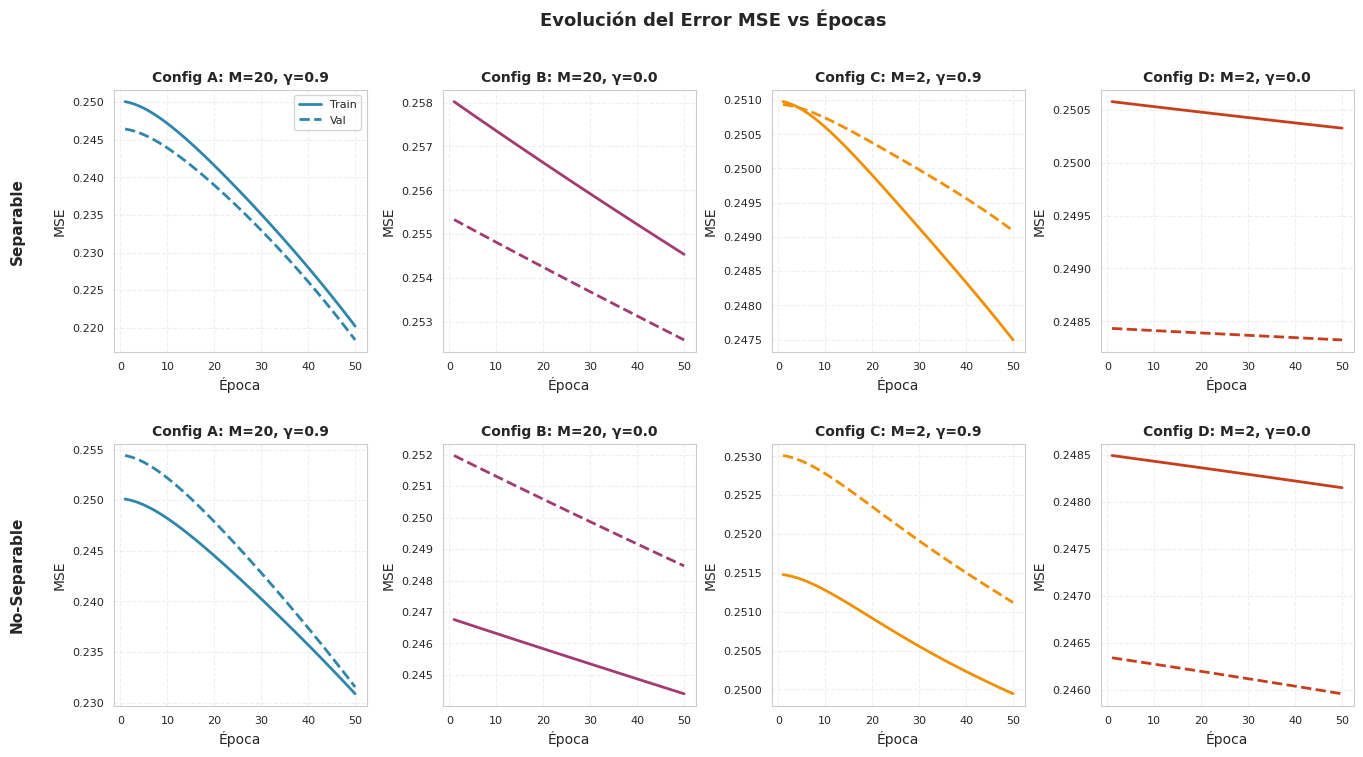

In [12]:
## @brief Genera la matriz 2×4 de curvas de error train/val por configuración.
fig = plot_error_matrix(results_sep, results_nosep,
                        output_path=FIGURES_DIR / 'error_matrix.pdf')
plt.show()

## 3.5 — Tabla de convergencia

In [13]:
## @brief Imprime la tabla de errores finales de validación por configuración.
print_convergence_table(results_sep, results_nosep)
convergence_dataframe(results_sep, results_nosep)


Config        Separable (val)   No-Separable (val)
----------------------------------------------------
Config A             0.218369             0.231552
Config B             0.252585             0.248465
Config C             0.249089             0.251118
Config D             0.248324             0.245959


,config,sep_train,sep_val,nosep_train,nosep_val
0,A,0.220207,0.218369,0.230880,0.231552
1,B,0.254539,0.252585,0.244399,0.248465
2,C,0.247495,0.249089,0.249943,0.251118
3,D,0.250327,0.248324,0.248148,0.245959


---
# Sección 4 — Clasificador de imágenes ACRIMA

Dataset: [ACRIMA en Kaggle](https://www.kaggle.com/datasets/toaharahmanratul/acrima-dataset) — imágenes de fondo de ojo etiquetadas con y sin glaucoma.

In [14]:
## @brief Descarga el dataset ACRIMA desde Kaggle usando kagglehub.
#  La primera ejecución descarga (~1 GB). Las siguientes usan la caché local.
ACRIMA_PATH = kagglehub.dataset_download('toaharahmanratul/acrima-dataset')
print(f'Dataset descargado en: {ACRIMA_PATH}')

100%|██████████| 22.9M/22.9M [00:00<00:00, 185MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/toaharahmanratul/acrima-dataset/versions/2


In [15]:
## @brief Realiza la normalización l infinito para cada imagen individual
def l_inf_normalize(img):
    img = img.astype(np.float32)
    max_val = np.max(img)

    if max_val>0:
        img = img / max_val

    return img